In [ ]:
import glob
import re
from collections import defaultdict
import pickle
import random
import ast
import numpy as np

def find_diagonal_distances_val(prob1,prob2):
    distance = np.sqrt((prob1 - 0.5)**2 + (prob2 - 0.5)**2)/(np.sqrt(2)/2)
    return distance

def compute_empirical_p_value(d_opt_orig, d_opt_neigh):
    d_opt_neigh = np.array(d_opt_neigh)
    count = np.sum(d_opt_neigh <= d_opt_orig)
    n = len(d_opt_neigh)
    p_value = count / n
    return p_value


with open('../fRNAhammingdistance.pkl', 'rb') as f:
    fRNAhammingdistance = pickle.load(f)

with open('../fRNAprob2.pkl', 'rb') as f:
    fRNAprob2 = pickle.load(f)

with open('../fRNAprob1.pkl', 'rb') as f:
    fRNAprob1 = pickle.load(f)

seqnums = []

RNAoptimalplasticity = defaultdict(dict)
RNAoptimalplasticity_samples = defaultdict(dict)
stable_sample_sizes = []
# Pattern to match the files
file_pattern = 'to_analyse_*_ssize5000.pkl'
files = glob.glob(file_pattern)
pval = []
pvalfull = []
for file in files:
    match = re.search(r'to_analyse_(.+)_ssize5000', file)
    if match:
        seqname_str = ''.join(match.group(1))
        seqname = ast.literal_eval(seqname_str)
    
        # Read the file into a DataFrame
        with open(file, 'rb') as f:
            data = pickle.load(f)
        probs1 = list(data['probs1'])
        probs2 = list(data['probs2'])
     
        d_obs = find_diagonal_distances_val(fRNAprob1[seqname], fRNAprob2[seqname])
        dataset = np.array([find_diagonal_distances_val(p1, p2) for p1, p2 in zip(probs1,probs2)])

    pval = compute_empirical_p_value(d_obs, dataset)

    if pval < 0.05:

        RNAoptimalplasticity[seqname][(fRNAhammingdistance[seqname], fRNAprob1[seqname], fRNAprob2[seqname])] = pval

In [ ]:
with open('../RNAoptimalplasticity.pkl', 'rb') as f:
    fRNAoptimalplasticity_10000 = pickle.load(f)

In [ ]:
len(fRNAoptimalplasticity_10000) # pvalue results of sequence sitescanning with 10000 samples

1382

In [183]:
for seq, inner_dict in fRNAoptimalplasticity_10000.items():
    if seq in RNAoptimalplasticity:
        #RNAoptimalplasticity[seq].update(inner_dict)
        continue
    else:
        RNAoptimalplasticity[seq] = inner_dict.copy()

In [139]:
RNAoptimalplasticity_cutoff = defaultdict(dict)
for name in RNAoptimalplasticity:
        if diagonal_distances[name] <= 0.35:
            RNAoptimalplasticity_cutoff[name] = RNAoptimalplasticity[name]
        

In [ ]:
import re

def extract_type(name):
    label = name[0]
    print(name)
    if '||' in label:
        desc = label.split('||', 1)[1]
    else:
        desc = label.split('|')[-1]
    desc = re.sub(r'\s*\(.*?\)', '', desc).strip()
    return desc

types = set()
for name in RNAoptimalplasticity_cutoff:
        types.add(extract_type(name))

print(types)

for type in types:
    print(type)

Fly small RNA
mature micro RNA miR-314-3p
Hepatitis C stem-loop IV
mature micro RNA hiv1-miR-H1-5p
mature micro RNA miR-33b-5p
mature micro RNA miR-160-5p / miR-160a-5p / miR-160b-5p / miR-160c-5p / miR-160d-5p / miR-160e-5p
mature micro RNA mdv2-miR-M27-3p
mature micro RNA miR-160b-5p
Putative conserved noncoding region
Prion pseudoknot
mature micro RNA miR-113
mature micro RNA miR-27a-3p
Piwi-interacting RNA


In [145]:
sequence_lengths = set()
sequence_lengths_list = []  # Add 0 for the empty sequence
for name in RNAoptimalplasticity_cutoff:
    #if fRNAhammingdistance[name] < 0.15:
        sequence = name[1]
        sequence_lengths.add(len(sequence))
        sequence_lengths_list.append(len(sequence))
        if len(sequence) == 50:
           print(name)
print(sequence_lengths)


{15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 43}


In [148]:
sequence_lengths_total = set()
sequence_lengths_list_total = []  # Add 0 for the empty sequence
for name in selected_for_analysis_new_cutoff:
        sequence = name[1]
        sequence_lengths_list_total.append(len(sequence))


In [152]:
sequence_lengths_total = set()
sequence_lengths_list_total = []  # Add 0 for the empty sequence
for name in selected_names:
        sequence = name[1]
        sequence_lengths_list_total.append(len(sequence))

In [156]:
len(selected_names)

237461

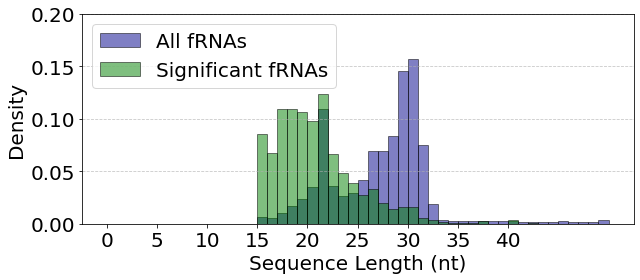

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))  # Adjust figure size

plt.hist(sequence_lengths_list_total, 
         bins=range(0, max(sequence_lengths_list_total) + 1), 
         edgecolor='black', 
         color='darkblue',density=True, alpha=0.5, label='All fRNAs')
plt.hist(sequence_lengths_list, 
         bins=range(0, max(sequence_lengths_list) + 1), 
         edgecolor='black', 
         color='green', density=True,alpha =0.5, label='Significant fRNAs')
#plt.title("Significant fRNAs", fontsize=20)
plt.xlabel("Sequence Length (nt)", fontsize=20)
plt.ylabel("Density", fontsize=20)
plt.yticks([0.0, 0.05, 0.10, 0.15, 0.20], fontsize=20)
plt.xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50], fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, max(sequence_lengths_list) + 1, 5))  # Tick every 5 nt

plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('fRNAlengths.pdf', bbox_inches='tight')
plt.show()


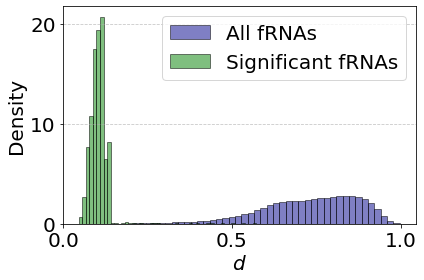

In [220]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # Adjust figure size

plt.hist(list(diagonal_distances.values()), 
         bins=50, 
         edgecolor='black', 
         color='darkblue', density=True,alpha =0.5, label='All fRNAs')
         
plt.hist(RNAoptimalplasticity_h_BH, 
         bins=50, 
         edgecolor='black', 
         color='green',density=True, alpha=0.5, label='Significant fRNAs')
#plt.title("Significant fRNAs", fontsize=20)
plt.xlabel(r"$d$", fontsize=20)
plt.ylabel("Density", fontsize=20)
plt.xticks([0, 0.5, 1], fontsize=20)
plt.yticks([0.0, 10,20.], fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig('fRNAdistances.pdf', bbox_inches='tight')
plt.show()

In [5]:
fRNAprob1[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')]

0.4098291156226088

In [192]:
fRNAprob2[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')]

0.4098291156226088

In [19]:
diagonal_distances[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')]

0.18034176875478236

In [ ]:
fRNAhammingdistance[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')]

0.4

BH correction

In [137]:
selected_for_analysis_new_cutoff = []
for d,h,n in zip(selected_min_distances, selected_hamming_values,selected_names):
    if d<=0.35:
        selected_for_analysis_new_cutoff.append(tuple(n))

In [147]:
len(selected_for_analysis_new_cutoff)

3685

In [170]:
3685/len(selected_names)

0.01551833774809337

In [140]:
def find_first_false_streak(comparison):
    for idx in range(len(comparison)):
        if all(not val for val in comparison[idx:]):
            return idx
    return None

def false_discovery_control(ps, *, axis=0, method='bh'):

    ps = np.asarray(ps)
    if method == 'bh':
        # Benjamini-Hochberg procedure
        shape = ps.shape
        ps = np.sort(ps, axis=axis)
        n = ps.shape[axis]
        i = np.arange(1, n + 1)
        threshold = 0.1*i/3685
        comparison = ps <= threshold
        false_indices = np.where(comparison == False)[0]
        first_false_streak_index = find_first_false_streak(comparison)
        if first_false_streak_index is not None:
            print(f"Index where comparison becomes consistently False: {first_false_streak_index}")
        else:
            print("No consistent False streak found in comparison")
        return comparison
    else:
        raise ValueError(f"Unknown method: {method}")


all_pvals = list(RNAoptimalplasticity_cutoff[seq][key] for seq in RNAoptimalplasticity_cutoff for key in RNAoptimalplasticity_cutoff[seq])
all_names = [seq for seq in RNAoptimalplasticity_cutoff for key in RNAoptimalplasticity_cutoff[seq]]

comparison = false_discovery_control(all_pvals, method='bh')

# Get the significant sequences
significant_sequences = [name for name, is_sig in zip(all_names, comparison) if is_sig]


No consistent False streak found in comparison


In [141]:
len(significant_sequences)

2412

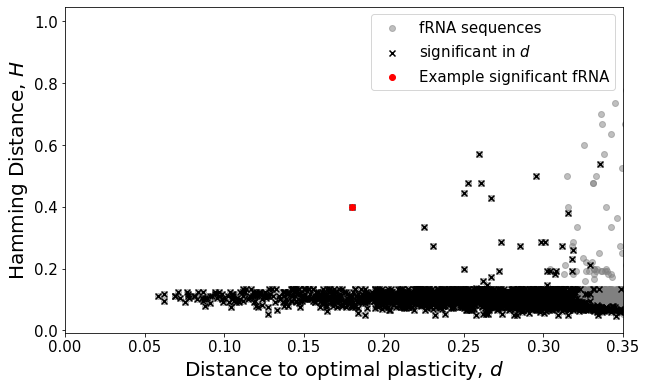

In [ ]:
from matplotlib import pyplot as plt 
import numpy as np

with open('fRNAfolds.pkl', 'rb') as f:
    fRNAfolds = pickle.load(f)
def find_diagonal_distances_dict(prob1,prob2):
    diagonal_distances = {}
    for x, y,key1,key2 in zip(prob1.values(), prob2.values(), prob1.keys(), prob2.keys()):
        if key1 == key2:
            diagonal_distances[key1] = find_diagonal_distances_val(x,y)
    return diagonal_distances
# Calculate the distance from the diagonal (0.5, 0.5)
diagonal_distances = find_diagonal_distances_dict(fRNAprob1, fRNAprob2)

selected_names = []
selected_hamming_values =[]
selected_min_distances = []
for name in fRNAhammingdistance.keys():
    if '.' * len(name[1]) not in fRNAfolds[name]:
        selected_names.append(name)
        selected_hamming_values.append(fRNAhammingdistance[name])
        selected_min_distances.append(diagonal_distances[name])
selected_names = np.array(selected_names)
selected_hamming_values = np.array(selected_hamming_values)
selected_min_distances = np.array(selected_min_distances)

basediff_similarones = defaultdict(list)
basediff_desimilarones = defaultdict(list)
similarones_d = []
similarones_h = []
similarones_l = []
desimilarones_d = []
desimilarones_h = []
desimilarones_l = []
not_in_selected_d = []
not_in_selected_h = []
selected_for_analysis_d = []
selected_for_analysis_h = []
names_to_analyse_d = []
names_to_analyse_h = []
in_selected_d = []
in_selected_h = []
RNAoptimalplasticity_d = []
RNAoptimalplasticity_h = []
RNAoptimalplasticity_d_BH = []
RNAoptimalplasticity_h_BH = []
selected_for_analysis_new_cutoff = []
for d,h,n in zip(selected_min_distances, selected_hamming_values,selected_names):
    if d<=0.35:
        selected_for_analysis_new_cutoff.append(tuple(n))


for name in significant_sequences:
    RNAoptimalplasticity_d_BH.append(diagonal_distances[name])
    RNAoptimalplasticity_h_BH.append(fRNAhammingdistance[name])

plt.figure(figsize=(10, 6))
plt.scatter(selected_min_distances, selected_hamming_values, c='grey', marker='o', alpha=0.5, label='fRNA sequences')
plt.scatter(RNAoptimalplasticity_d_BH, RNAoptimalplasticity_h_BH, c='k', marker='x', alpha=1.0, label=r'significant in $d$')
#plt.scatter(RNAoptimalplasticity_d, RNAoptimalplasticity_h, c='k', marker='x', alpha=1.0, label=r'significant in $d$')
plt.scatter(diagonal_distances[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')], fRNAhammingdistance[('FR412344||Fly small RNA', 'AAGGCAACCCCGCCAGCCTA')], c='red', marker='o', alpha=1.0, label='Example significant fRNA')
# Add labels and title
plt.ylabel(r'Hamming Distance, $H$', fontsize=20)
plt.xlabel(r'Distance to optimal plasticity, $d$', fontsize=20)
#plt.title('Selected fRNA sequences for analysis', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15) 
plt.legend(fontsize=15)
plt.xlim(xmin=0, xmax=0.35)

# Show the plot
plt.savefig('fRNAoptimalplasticity.pdf', bbox_inches='tight')
plt.show()

# stability of site-scanning sampling


In [176]:
with open('RNAoptimalplasticity.pkl', 'rb') as f:
    RNAoptimalplasticity_samples10000 = pickle.load(f)

In [177]:
len(RNAoptimalplasticity_samples10000)

1382

In [ ]:
with open('../data/datatoanalyse/to_analyse.pkl', 'rb') as f:
    names_to_analyse = pickle.load(f)

In [ ]:
import glob
import re
import random
import pickle
import numpy as np
from collections import defaultdict
# Path to the data folder
seqnums = []
data_folder = '../data/datatoanalyse/'
RNAoptimalplasticity = defaultdict(dict)
RNAoptimalplasticity_samples = defaultdict(dict)
stable_sample_sizes = []

# Pattern to match the files
file_pattern = data_folder + 'to_analyse*_ssize10000.pkl'
files = glob.glob(file_pattern)
random.seed(1)
random_files = random.sample(files, 1000)  # 10 different files

sample_sizes = [10000,5000,1000,100]
pval_by_sample_size = {size: [] for size in sample_sizes}
pvalfull = []

def find_diagonal_distances_val(prob1,prob2):
    distance = np.sqrt((prob1 - 0.5)**2 + (prob2 - 0.5)**2)/(np.sqrt(2)/2)
    return distance

for file in random_files:
    match = re.search(r'to_analyse(\d+)_ssize10000', file)
    if match:
        seq_number = int(match.group(1))
        seqnums.append(seq_number)
        with open(file, 'rb') as f:
            data = pickle.load(f)
        probs1full = list(data['probs1'])
        probs2full = list(data['probs2'])
        d_obs = find_diagonal_distances_val(
            fRNAprob1[tuple(names_to_analyse[seq_number])],
            fRNAprob2[tuple(names_to_analyse[seq_number])]
        )
        datasetfull = np.array([find_diagonal_distances_val(p1, p2) for p1, p2 in zip(probs1full, probs2full)])

        pvalfull.append(compute_empirical_p_value(d_obs, datasetfull))
        for size in sample_sizes:
            if size <= len(datasetfull):
                idx = np.random.choice(len(datasetfull), size=size, replace=False)
                dataset = datasetfull[idx]
                pval = compute_empirical_p_value(d_obs, dataset)
                pval_by_sample_size[size].append(pval)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for size in [10000,5000,1000,100]:
    plt.scatter(pvalfull, pval_by_sample_size[size],label=f"n={size}", alpha=0.7, marker='o')
plt.plot([0,0.5], [0,0.5], color='black', linestyle='--', linewidth=1)
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel("p-value of 10000 samples")
plt.ylabel("Empirical p-value")
plt.title("Empirical p-values for different sample sizes")
plt.legend()
plt.tight_layout()
plt.show()